In [230]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [231]:
data = pd.read_csv("googleplaystore.csv")
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [232]:
data = data[data['Rating'] <= 5]   
data = data[data['Rating'] >= 1]
data


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10834,FR Calculator,FAMILY,4.0,7,2.6M,500+,Free,0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [233]:
data = data.dropna(subset=['Rating']) 

In [234]:
data['Installs'] = data['Installs'].str.replace(',', '')
data['Installs'] = data['Installs'].str.replace('+', '')
data['Installs'] = data['Installs'].astype(int)

In [235]:
data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10834,FR Calculator,FAMILY,4.0,7,2.6M,500,Free,0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,5000,Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,1000,Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [236]:
data['Price'] = data['Price'].str.replace('$', '')
data['Price'] = data['Price'].astype(float)

In [237]:
def convert_size(size):
    if 'M' in size:
        return float(size.replace('M', '')) * 1e6
    elif 'k' in size:
        return float(size.replace('k', '')) * 1e3
    else:
        return None

data['Size'] = data['Size'].apply(convert_size)

In [238]:
data['Reviews'] = data['Reviews'].astype(int)

<Axes: >

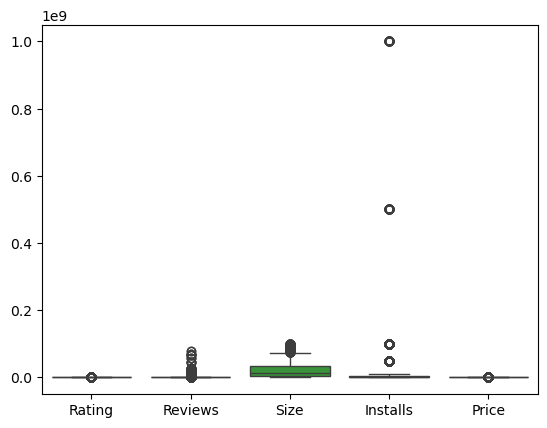

In [239]:


sns.boxplot(data=data)

In [240]:
data.isna().sum()

App                  0
Category             0
Rating               0
Reviews              0
Size              1637
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          4
Android Ver          2
dtype: int64

In [241]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] >= lower) & (df[column] <= upper)]

In [242]:
data['Size'].fillna(data['Size'].median(), inplace=True)

C:\Users\Sarika\AppData\Local\Temp\ipykernel_20740\2799437417.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Size'].fillna(data['Size'].median(), inplace=True)


In [243]:
data.isna().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       4
Android Ver       2
dtype: int64

In [244]:
data['Current Ver'].fillna(data['Current Ver'].mode()[0], inplace=True)
data['Android Ver'].fillna(data['Android Ver'].mode()[0], inplace=True)

C:\Users\Sarika\AppData\Local\Temp\ipykernel_20740\1580882867.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Current Ver'].fillna(data['Current Ver'].mode()[0], inplace=True)
C:\Users\Sarika\AppData\Local\Temp\ipykernel_20740\1580882867.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [245]:
data = data.drop(['App', 'Current Ver', 'Android Ver', 'Last Updated'], axis=1)

In [246]:
data['Genres'] = data['Genres'].apply(lambda x: x.split(';')[0])

In [247]:
data = pd.get_dummies(data, columns=[
    'Category', 'Type', 'Content Rating', 'Genres'
], drop_first=True)

In [248]:
print(data.shape)

(9366, 90)


In [249]:
data.head()

,Rating,Reviews,Size,Installs,Price,Category_AUTO_AND_VEHICLES,Category_BEAUTY,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMICS,...,Genres_Simulation,Genres_Social,Genres_Sports,Genres_Strategy,Genres_Tools,Genres_Travel & Local,Genres_Trivia,Genres_Video Players & Editors,Genres_Weather,Genres_Word
0,4.1,159,19000000.0,10000,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,3.9,967,14000000.0,500000,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,4.7,87510,8700000.0,5000000,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4.5,215644,25000000.0,50000000,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,4.3,967,2800000.0,100000,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [250]:
import numpy as np

X['Reviews'] = np.log1p(X['Reviews'])
X['Installs'] = np.log1p(X['Installs'])
X['Size'] = np.log1p(X['Size'])
X['Price'] = np.log1p(X['Price'])

In [251]:
X = data.drop('Rating', axis=1)
y = data['Rating']

In [252]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [253]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [254]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("R2:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))


Linear Regression
R2: 0.017431988877961713
MSE: 0.24221475897026104
RMSE: 0.49215318648796846


In [255]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print("R2:", r2_score(y_test, y_pred_dt))
print("RMSE:", mean_squared_error(y_test, y_pred_dt))


Decision Tree
R2: -0.5645178846111352
RMSE: 0.38567235859124865


In [256]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN")
print("R2:", r2_score(y_test, y_pred_knn))
print("RMSE:", mean_squared_error(y_test, y_pred_knn))

KNN
R2: -0.06916955090564514
RMSE: 0.2635630736392743


In [257]:
import numpy as np

X['Reviews'] = np.log1p(X['Reviews'])
X['Installs'] = np.log1p(X['Installs'])
X['Size'] = np.log1p(X['Size'])
X['Price'] = np.log1p(X['Price'])

In [258]:
data['Reviews_per_install'] = data['Reviews'] / (data['Installs'] + 1)

In [259]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,        # more trees → better learning
    max_depth=15,            # prevents overfitting
    min_samples_split=5,     # avoids very small splits
    min_samples_leaf=2,      # smoother predictions
    max_features='sqrt',     # reduces randomness noise
    bootstrap=True,
    random_state=42,
    n_jobs=-1                # uses all CPU cores
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [260]:
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score

print("Improved Random Forest")
print("R2:", r2_score(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf))


Improved Random Forest
R2: 0.12815455316398316
RMSE: 0.21492032345278217


In [261]:
baseline_value = y_train.mean()

y_pred_baseline = np.full_like(y_test, baseline_value)

# convert to classification (rounding)
y_pred_base_class = y_pred_baseline.round()
y_test_class = y_test.round()

print("Training Accuracy:", accuracy_score(y_test_class, y_pred_base_class))

Training Accuracy: 0.7049092849519744


In [262]:
y_pred_class = np.clip(y_pred_rf.round(), 1, 5)
y_test_class = np.clip(y_test.round(), 1, 5)

In [263]:
print("Testing Accuracy:", accuracy_score(y_test_class, y_pred_class))

Testing Accuracy: 0.7107790821771611


In [265]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(X.columns, open("columns.pkl", "wb"))

In [266]:
print(columns)

NameError: name 'columns' is not defined

In [267]:
st.write(columns)


NameError: name 'st' is not defined

In [270]:
print(X.columns)
columns=X.columns

Index(['Reviews', 'Size', 'Installs', 'Price', 'Category_AUTO_AND_VEHICLES',
       'Category_BEAUTY', 'Category_BOOKS_AND_REFERENCE', 'Category_BUSINESS',
       'Category_COMICS', 'Category_COMMUNICATION', 'Category_DATING',
       'Category_EDUCATION', 'Category_ENTERTAINMENT', 'Category_EVENTS',
       'Category_FAMILY', 'Category_FINANCE', 'Category_FOOD_AND_DRINK',
       'Category_GAME', 'Category_HEALTH_AND_FITNESS',
       'Category_HOUSE_AND_HOME', 'Category_LIBRARIES_AND_DEMO',
       'Category_LIFESTYLE', 'Category_MAPS_AND_NAVIGATION',
       'Category_MEDICAL', 'Category_NEWS_AND_MAGAZINES', 'Category_PARENTING',
       'Category_PERSONALIZATION', 'Category_PHOTOGRAPHY',
       'Category_PRODUCTIVITY', 'Category_SHOPPING', 'Category_SOCIAL',
       'Category_SPORTS', 'Category_TOOLS', 'Category_TRAVEL_AND_LOCAL',
       'Category_VIDEO_PLAYERS', 'Category_WEATHER', 'Type_Paid',
       'Content Rating_Everyone', 'Content Rating_Everyone 10+',
       'Content Rating_Mature 

In [271]:
# create empty dataframe
input_df = pd.DataFrame(columns=columns)
input_df.loc[0] = 0

# numeric
input_df['Reviews'] = reviews_log
input_df['Size'] = size_log
input_df['Installs'] = installs_log
input_df['Price'] = price_log

# Category
cat_col = f'Category_{category}'
if cat_col in columns:
    input_df[cat_col] = 1

# Type (IMPORTANT FIX)
if 'Type_Paid' in columns:
    input_df['Type_Paid'] = 1 if type_app == 'Paid' else 0

# Content Rating
cr_col = f'Content Rating_{content_rating}'
if cr_col in columns:
    input_df[cr_col] = 1

# Genres
gen_col = f'Genres_{genres}'
if gen_col in columns:
    input_df[gen_col] = 1

# 🔥 MOST IMPORTANT LINE
input_df = input_df.reindex(columns=columns, fill_value=0)

NameError: name 'reviews_log' is not defined